In [1]:
from google.colab import files
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail (3).xlsx


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset from UCI ML Repository (hosted copy)
df = pd.read_excel("Online Retail.xlsx")

# Basic cleaning
df = df.dropna(subset=['InvoiceNo', 'Description'])
df = df[df['Quantity'] > 0]

# Keep only relevant columns
df = df[['InvoiceNo', 'Description']]

# Show first rows
df.head()

,InvoiceNo,Description
0,536365,WHITE HANGING HEART T-LIGHT HOLDER
1,536365,WHITE METAL LANTERN
2,536365,CREAM CUPID HEARTS COAT HANGER
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE
4,536365,RED WOOLLY HOTTIE WHITE HEART.


/tmp/ipython-input-1526591288.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=item_counts.index, x=item_counts.values, palette='viridis')


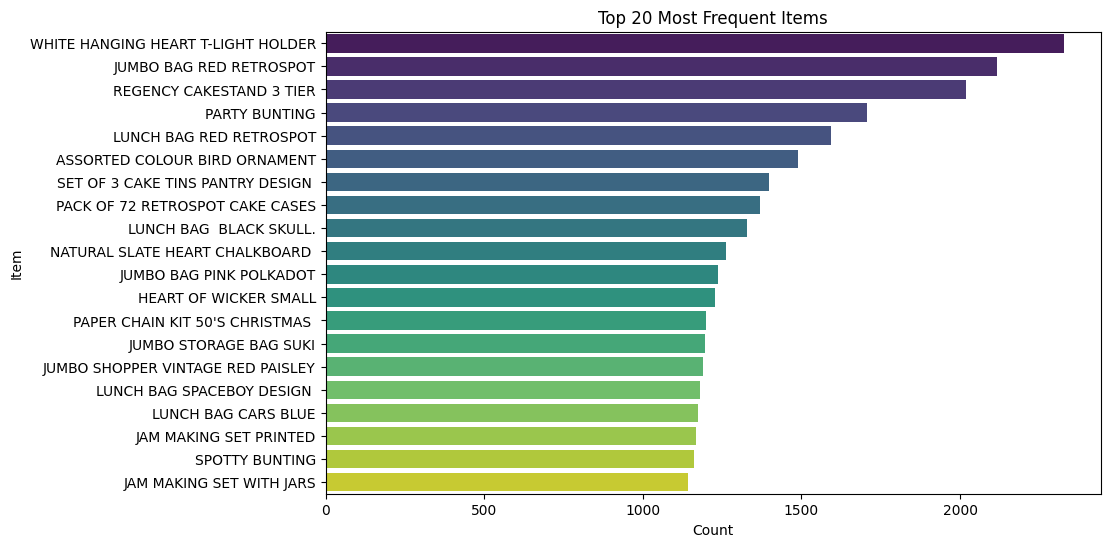

/tmp/ipython-input-1526591288.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)


In [3]:
item_counts = df['Description'].value_counts().head(20)

plt.figure(figsize=(10,6))
sns.barplot(y=item_counts.index, x=item_counts.values, palette='viridis')
plt.title('Top 20 Most Frequent Items')
plt.xlabel('Count')
plt.ylabel('Item')
plt.show()

top_items = df['Description'].value_counts().head(100).index  # keep top 100 items
df_small = df[df['Description'].isin(top_items)]

basket = (df_small.groupby(['InvoiceNo', 'Description'])['Description']
          .count().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)

/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Top 10 frequent itemsets (Apriori):


/tmp/ipython-input-530862458.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frequent_itemsets_ap.head(10)['support'],


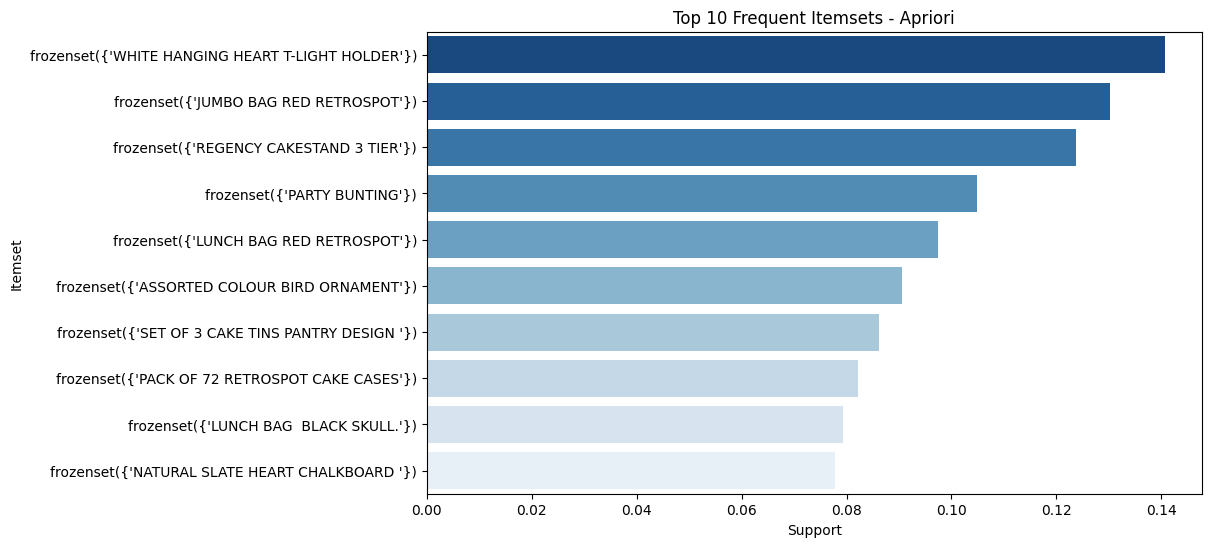

In [4]:
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

min_support = 0.05  # Adjust based on dataset size

frequent_itemsets_ap = apriori(basket_sets, min_support=min_support, use_colnames=True)
frequent_itemsets_ap = frequent_itemsets_ap.sort_values('support', ascending=False)

print("Top 10 frequent itemsets (Apriori):")
frequent_itemsets_ap.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=frequent_itemsets_ap.head(10)['support'],
            y=frequent_itemsets_ap.head(10)['itemsets'].astype(str),
            palette='Blues_r')
plt.title('Top 10 Frequent Itemsets - Apriori')
plt.xlabel('Support')
plt.ylabel('Itemset')
plt.show()

/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Top 10 frequent itemsets (FP-Growth):


/tmp/ipython-input-990190695.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frequent_itemsets_fp.head(10)['support'],


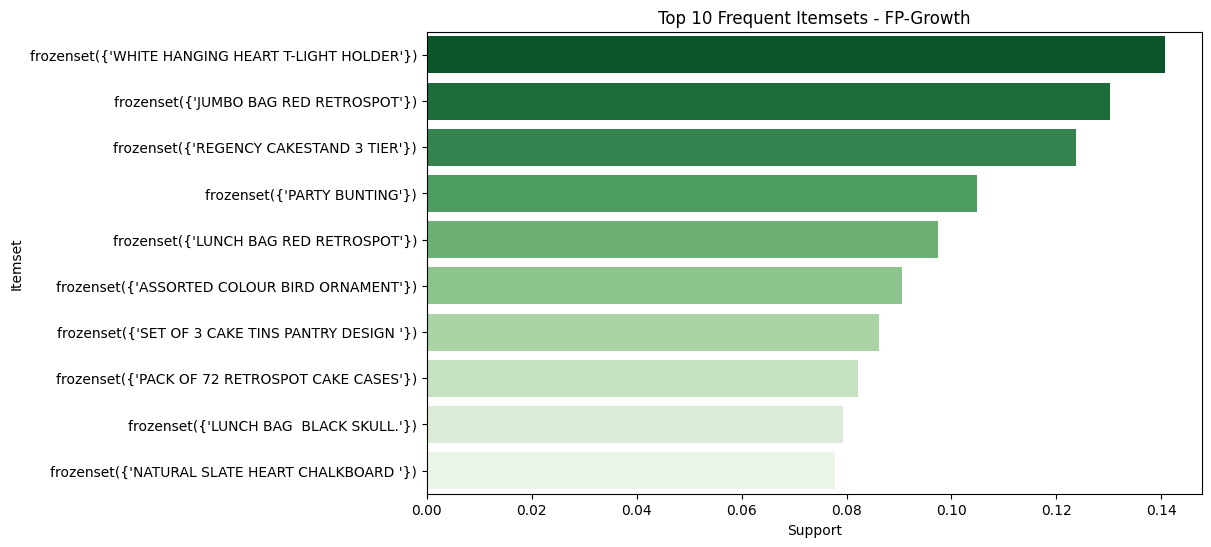

In [5]:
frequent_itemsets_fp = fpgrowth(basket_sets, min_support=min_support, use_colnames=True)
frequent_itemsets_fp = frequent_itemsets_fp.sort_values('support', ascending=False)

print("Top 10 frequent itemsets (FP-Growth):")
frequent_itemsets_fp.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=frequent_itemsets_fp.head(10)['support'],
            y=frequent_itemsets_fp.head(10)['itemsets'].astype(str),
            palette='Greens_r')
plt.title('Top 10 Frequent Itemsets - FP-Growth')
plt.xlabel('Support')
plt.ylabel('Itemset')
plt.show()

Sample Apriori rules:


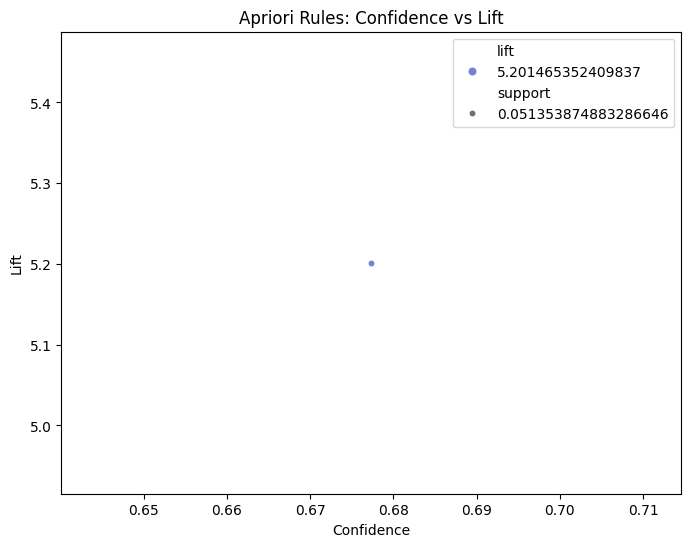

In [6]:
conf_threshold = 0.5

rules_ap = association_rules(frequent_itemsets_ap, metric="confidence", min_threshold=conf_threshold)
rules_fp = association_rules(frequent_itemsets_fp, metric="confidence", min_threshold=conf_threshold)

print("Sample Apriori rules:")
rules_ap.head()

plt.figure(figsize=(8,6))
sns.scatterplot(data=rules_ap, x='confidence', y='lift', size='support',
                hue='lift', palette='coolwarm', sizes=(20, 200), alpha=0.7)
plt.title('Apriori Rules: Confidence vs Lift')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.show()

In [7]:
import time

# Timing Apriori
start = time.time()
apriori(basket_sets, min_support=min_support, use_colnames=True)
time_ap = time.time() - start

# Timing FP-Growth
start = time.time()
fpgrowth(basket_sets, min_support=min_support, use_colnames=True)
time_fp = time.time() - start

print(f"Apriori algorithm took: {time_ap:.4f} seconds")
print(f"FP-Growth algorithm took: {time_fp:.4f} seconds")

print(f"Apriori found {len(frequent_itemsets_ap)} frequent itemsets")
print(f"FP-Growth found {len(frequent_itemsets_fp)} frequent itemsets")


/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Apriori algorithm took: 0.3325 seconds
FP-Growth algorithm took: 0.8065 seconds
Apriori found 65 frequent itemsets
FP-Growth found 65 frequent itemsets
